# **Main notebook**

## **I. Engineering financial features for time-series stock data**

- Slice the data into our period of interest (2015-01-01 to 2019-12-31).

Obtain: 

**Per stock (daily)**
- Price (close)
- Adj. returns
- Avg. returns over the previous 3 & 7 days 
- SD of adj. closing prices (monthly)
- Volume

**Global (daily)**
- S&P volume
- S&P returns
- VIX (all market return)

**Targets**
- t1: returns from t+1 MO to t+1 MC 
- t8: returns from t+1 MO to t+8 MO
- t7: returns from t+1 MO to t+7 MC

We obtain historical stock prices from the instruction files. ^SPX and ^VIX are from [FRED](https://fred.stlouisfed.org/categories/46). 

In [8]:
import pandas as pd
import numpy as np 

dfSPX = pd.read_csv(f'data/Stock_price/^SPX.csv', sep=';')
dfSPX['date'] = pd.to_datetime(dfSPX['Date'])
dfSPX = dfSPX.set_index('date').sort_index()

dfSPX['dlyretSPX'] = dfSPX['Close'].pct_change()
dfSPX['volumeSPX'] = dfSPX['Volume']
dfSPX = dfSPX.loc['2015-01-01':'2019-12-31', ['dlyretSPX', 'volumeSPX']]

dfVIX = pd.read_csv(f'data/Stock_price/^VIX.csv', sep=';')
dfVIX['date'] = pd.to_datetime(dfVIX['observation_date'])
dfVIX = dfVIX.set_index('date').sort_index()
dfVIX = dfVIX.loc['2015-01-01':'2019-12-31', ['VIXCLS']].rename(columns={'VIXCLS': 'VIX'})

dfGlobal = dfSPX.join(dfVIX, how='inner')

In [9]:
tickers = ("AAPL", "AMZN", "GOOG", "GOOGL", "MSFT", "TSLA")
df = {}

for ticker in tickers:
    
    # Loading data per ticker
    df_temp = pd.read_csv(f'data/Stock_price/{ticker}.csv')
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp = df_temp.set_index('date').sort_index()
    
    # Filtering time window: 2015-01-01 to 2019-12-31 (margin for returns and SD)
    df_temp = df_temp.loc['2014-12-01':'2020-01-31']


    df_temp['price'] = df_temp['close']
    df_temp['dlyret'] = df_temp['adj close'].pct_change() # Daily adjusted returns
    df_temp['logVolume'] = np.log(df_temp['volume'].clip(lower=1)) 

    df_temp['past_3ret'] = df_temp['dlyret'].rolling(3).mean() # Previous 3 days mean adjusted returns
    df_temp['past_7ret'] = df_temp['dlyret'].rolling(7).mean() # Previous 7 days mean adjusted returns
    df_temp['sdAdjClose'] = df_temp['adj close'].rolling(20).std() # SD of adjusted closing prices, one trading month

    #df_temp['ret1'] = df_temp['dlyret'].shift(-1)  # Forward return from t to t+1
    #df_temp['ret7'] = (df_temp['price'].shift(-7) - df_temp['price']) / df_temp['price'] # Forward return from t to t+7

    df_temp['ret1'] = (df_temp['close'].shift(-1) - df_temp['open'].shift(-1)) / df_temp['open'].shift(-1) 
    df_temp['ret8'] = (df_temp['open'].shift(-8) - df_temp['open'].shift(-1)) / df_temp['open'].shift(-1)
    df_temp['ret7'] = (df_temp['close'].shift(-7) - df_temp['open'].shift(-1)) / df_temp['open'].shift(-1)

    # We compute metrics only for the period of interest
    df_temp = df_temp.loc['2015-01-01':'2019-12-31', ['price', 'volume', 'dlyret', 'sdAdjClose', 'past_3ret', 'past_7ret', 'ret1', 'ret7']]

    # Merging with global features
    df_temp = df_temp.join(dfGlobal, how='left')
    df[ticker] = df_temp

    # Create individual df: dfAAPL exists. Without this line: df['AAPL'] instead
    globals()[f'df{ticker}'] = df[ticker]    

## **II. News headlines**

We scrape the Financial Times pages for each firm of interest.

In [ ]:
from bs4 import BeautifulSoup
import requests
import time
import pandas as pd

SOURCES = {
    "AAPL":     ("apple-inc",                                    39),
    "AMZN":    ("stream/84cf4073-a674-4a93-aef9-dcc1832a65cb", 33),
    "GOOG":  ("stream/6656b3e4-1a78-4960-90a0-8d422450f9a6", 11),
    "GOOGL":    ("stream/d6b12f0c-bf3f-4045-a07b-1e4e49103fd6", 32),
    "MSFT": ("stream/4f447b5d-53f5-41bd-ab42-3c0cfc161699", 25),
    "TSLA":     ("stream/35edec46-ef7b-4f9b-b85a-25174e6e07fa", 32),
}

def scrape_ft_topic(slug, start_page, ticker):
    articles = []
    page = start_page
    while True:
        url = f"https://www.ft.com/{slug}?page={page}"
        r = requests.get(url)
        soup = BeautifulSoup(r.text, "html.parser")
        items = soup.select(".stream-item[data-id]")

        if not items:
            print(f"\n  [{ticker}] page {page}: no items, stopping")
            break

        for item in items:
            title_tag = item.select_one(".o-teaser__heading a")
            li = item.find_parent("li")
            time_tag = li.find("time") if li else None
            if not title_tag:
                continue

            date = time_tag["datetime"][:10] if time_tag else ""
            title = title_tag.get_text(strip=True)

            if title.startswith("Lex."):
                title = title[len("Lex."):].strip()

            if date and date[:4] < "2015":
                print(f"\n  [{ticker}] p{page}: reached {date}, stopping")
                return articles

            if date and date[:4] < "2020":
                articles.append({"ticker": ticker, "date": date, "title": title})

        print(f"Scraping {ticker}: Page {page}, {len(articles)} articles", end="\r")
        page += 1
        time.sleep(1)

    return articles


all_articles = []
for ticker, (slug, start_page) in SOURCES.items():
    arts = scrape_ft_topic(slug, start_page, ticker)
    all_articles.extend(arts)

dfHL = pd.DataFrame(all_articles)
dfHL = dfHL.drop_duplicates(subset=["title", "date", "ticker"])
dfHL = dfHL.sort_values(["ticker", "date"], ascending=[True, False])

print(f"\nTotal: {len(dfHL)} articles")
print(dfHL.groupby("ticker").size())
dfHL.to_csv("data/output/HL_FinTimes_raw.csv", index=False)

Scraping AAPL: Page 150, 2776 articles
  [AAPL] p151: reached 2014-12-31, stopping
Scraping AMZN: Page 92, 1491 articles
  [AMZN] p93: reached 2014-12-29, stopping
Scraping GOOG: Page 87, 1912 articles
  [GOOG] p88: reached 2014-12-30, stopping
Scraping GOOGL: Page 53, 517 articles
  [GOOGL] page 54: no items, stopping
Scraping MSFT: Page 56, 793 articles
  [MSFT] p57: reached 2014-12-28, stopping
Scraping TSLA: Page 63, 782 articles
  [TSLA] p64: reached 2014-12-30, stopping

Total: 8307 articles
company
AAPL     2784
AMZN     1488
GOOG     1920
GOOGL     514
MSFT      810
TSLA      791
dtype: int64


We scrape 8308 FT articles headlines: that is less than 1 article per day per firm over the 5-year period we are studying. After cleaning, we keep 3898 articles: the FT includes a lot of articles that aren't relevant. 

As a solution, we scrape other news sources. Instead of designed spiders for each individual news-website (most often would be challening as they have protection against this kind of scraping), we simply leverage Google search engine with such query: "intitle:{keyword} site:www.{site}.com after:2014-12-31 before:2020-01-01".

Using technique, we scrape the following keywords:
- AAPL: Apple, Iphone, Steve Jobs, Tim Cook, iPade, AirPods, MacBook
- AMZN: Amazon, Jeff Bezos, AWS
- GOOG/GOOGL: Google, Sundar Pichai, Alphabet
- MSFT: Satya Nadella, Microsoft
- TSLA: Tesla, Model 3, Elon Musk.


We execute these queries for the following news sources: Reuters, The Guardian, Bloomberg, The New York Times, The Wall Street Journal, CNBC, BBC.

After scraping, we obtain 9011 articles. Cleaning is required. Leverageing special characters, we remove all headlines in foreign languages. As for thematics, we remove headlines mentioning apples (fruits) and the Amazon (forest). =Among the remaning headlines, despite using serious source-news, a lot aren't serious market-moving information, but noisy guides and other consumer-oriented article, among all sources. Hence, we remove headlines mentioning "How...", "review", "games", "which", "tips", "tricks", "best", "app", "guide", "opinion", "What...", "Why...", "How...", etc. We manually execute this last cleaning method: xxxx headlines are remaining.

*We made the choice not to leverage Yahoo Finance. Despite providing market-oriented news only, the quality of certain sources are questionable, often more oriented towards sensational day traders and not institutional quality news.*

We have a total of 11532 headlines.

We scrape 6387 FT articles headlines: that is less than 1 article per day per firm over the 5-year period we are studying. To counter this issue, we scrape other news sources. To avoid building individual scrapers tailored for each website's security measures, we leverage Google search engine with custom queries such as "intitle:"{keyword}" site:www.{site}.com after:2014-12-31 before:2020-01-01".

For keywords, we scrape: 
- AAPL: Apple, iPhone, Steve Jobs, Tim Cook, iPad, AirPods, Macbook
- AMZN: Amazon, Jeff Bezos, AWS
- GOOG/GOOGL: Google, Sundar Pichai, Alphabet
- MSFT/ Satya Nadella, Microsoft
- TSLA: Tesla, Model 3, Elon Musk.

As for news sources, we use Reuters, Bloomberg, The Guardian, The New York Times, The Wall Street Journal, CNBC and BBC.

This method has some limitations: headlines are sometimes truncated, or mention irrelevant topics. Hence, we filter all foreign language headlines, those mentioning the Amazon rainforest or apples as a fruit, as well as many consumer-oriented articles that some of these serious information sources provide.



## **III. Tweeter sentiment analysis**

- Load tweets
- Define influential tweets
- Compute sentiment: VADER, Bag of Words, TextBlob, roBERTa

We first load tweets: they have already been filtered from spam, and finBERT sentiment has been computed.

In [48]:
dfTweets = pd.read_csv(f'data/output/FinBERT_sentiment.csv')

### **III.A. Influential Tweets**

We then define which tweets are influential. A tweet is defined as influential if any of its metrics (comment_num, retweet_num, like_num) exceed the 99th percentile for those metrics. We distinguish influential tweets from non-influential tweets (SHAO et al., 2025).

In [12]:
com99th, rt99th, like99th = dfTweets['comment_num'].quantile(0.99), dfTweets['retweet_num'].quantile(0.99), dfTweets['like_num'].quantile(0.99)

print(f"99th comments: {com99th}\n99th RT: {rt99th}\n99th like: {like99th}")

# Influential: if any of its metric is above the 99th threshold
dfTweets['influential'] = (
    (dfTweets['comment_num'] > com99th) |
    (dfTweets['retweet_num'] > like99th) |
    (dfTweets['like_num'] > like99th)
)

99th comments: 6.0
99th RT: 11.0
99th like: 45.0


### **III.B. Sentiment analysis**

We then proceed with various types of sentiment analysis: VADER, TextBlob, Bag of Words, roBERTa. 

#### **III.B.1. VADER**

[VADER](https://github.com/cjhutto/vaderSentiment) sentiment analysis. Instead of using the compound score, we substract the negative sentiment scores from positive sentiment scores as our final variable (SHAO et al., 2025).

We compute VADER scores for both tweets and headlines.

In [19]:
dfFT = pd.read_csv("data/output/HL_FinTimes_cleaned.csv", sep=';')
dfAll = pd.read_csv("data/output/HL_all_cleaned.csv", sep=";")

dfHL = pd.concat([dfFT, dfAll], ignore_index=True)

In [21]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

tweets = dfTweets["body"].fillna('').astype(str)
headlines = dfHL["headline"].fillna('').astype(str)
analyzer = SentimentIntensityAnalyzer()

In [58]:
# 2min
vader_score = []
for tweet in tweets:
    vs = analyzer.polarity_scores(tweet)
    vader_score.append(vs['pos'] - vs['neg'])

dfTweets['VADER'] = vader_score

In [22]:
vader_H_score = []
for headline in headlines:
    vs = analyzer.polarity_scores(headline)
    vader_H_score.append(vs['pos'] - vs['neg'])

dfHL['VADER'] = vader_H_score

#### **III.2.2. Bag of Words (BoW)**

$$\text{BoW score}=
\begin{cases}
\frac{\text{count}_p-\text{count}_n}{\text{count}_p+\text{count}_n}, & \text{if count}_p + \text{count}_n > 0 ;\\
0, & \text{otherwise} ;
\end{cases}
$$

Where $\text{count}_p$ and $\text{count}_n$ denote the count of positive and negative words, respectively.

NLTK initial vocabulary is limited: we add some positive and negative financial jargon to its vocabulary, but the NLKT opinion lexicon still yields discrete sentiment scores (-1, 0, 1) for most tweets due to its limited coverage.

In [23]:
from nltk.corpus import opinion_lexicon
from nltk.tokenize import word_tokenize
import nltk

# Needed ressources
nltk.download('opinion_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab')

pos_words = set(opinion_lexicon.positive()) # # positive words
neg_words = set(opinion_lexicon.negative())# # negative words

# We add some financial jargon that wasn't in the opinion lexicon
fin_pos = {"surge", "profit", "uptrend", "beat", "buy", "bull", "skyrocket"}
fin_neg = {"plunge", "selloff", "underperform", "downtrend", "sell", "bear", "bankruptcy", "bankrupt"}

pos_words.update(fin_pos)
neg_words.update(fin_neg)

[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /Users/eyquem/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /Users/eyquem/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/eyquem/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [61]:
# 2min (Tweets)
BoW_scores = []
for tweet in tweets:
    tokens = word_tokenize(tweet.lower())
    count_p = sum(1 for token in tokens if token in pos_words)
    count_n = sum(1 for token in tokens if token in neg_words)

    # BoW score formula
    if count_p + count_n > 0: BoW_score = (count_p - count_n) / (count_p + count_n)
    else: BoW_score = 0.0

    BoW_scores.append(BoW_score)

dfTweets['BoW'] = BoW_scores

In [24]:
BoW_H_scores = []

for headline in headlines:
    Htokens = word_tokenize(headline.lower())
    count_p = sum(1 for Htoken in Htokens if Htoken in pos_words)
    count_n = sum(1 for Htoken in Htokens if Htoken in neg_words)

    # BoW score formula
    if count_p + count_n > 0: BoW_H_score = (count_p - count_n) / (count_p + count_n)
    else: BoW_H_score = 0.0

    BoW_H_scores.append(BoW_H_score)

dfHL['BoW'] = BoW_H_scores

#### **III.B.3. TextBlob (TB)**

We use TextBlob for further sentiment analysis. TB alread provides a sentiment polarity score in the range [-1, 1].

In [25]:
from textblob import TextBlob

In [65]:
#3m
TB_scores = []

for tweet in tweets:
    TB = TextBlob(tweet)
    TB_scores.append(TB.sentiment.polarity)

dfTweets['TBlob'] = TB_scores
dfTweets.to_csv("data/output/tweets_preRoBERTa.csv")

In [26]:
TB_H_scores = []

for headline in headlines:
    TB_H = TextBlob(headline)
    TB_H_scores.append(TB_H.sentiment.polarity)

dfHL['TBlob'] = TB_H_scores

#### **III.B.4. RoBERTa**

We use a [pre-trained RoBERTa model fine-tuned for sentiment analysis](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest).

Sentiment of the model: 0: = Negative; 1 = Neutral; 2 = Positive

We access the model via HuggingFace.

In [27]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoConfig
from scipy.special import softmax
from tqdm import tqdm

# Model config
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

def preprocess(text):
    if not isinstance(text, str):
        return ""
    new_text = []
    for t in text.split(" "):
        new_text.append(t)
    return " ".join(new_text)

def get_RoBERTa_score(text):
    try:
        text = preprocess(text)
        encoded_input = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
        output = model(**encoded_input)
        scores = output[0][0].detach().numpy()
        scores = softmax(scores)
        
        score = scores[2] - scores[0] # positive - negative
        return score
    except:
        return 0.0

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 32508.97it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [67]:
dfTweets = pd.read_csv("data/output/tweets_preRoBERTa.csv")
begin, to = 0, 100
tqdm.pandas(desc="RoBERTa sentiment")
dfTweets['RoBERTa'] = dfTweets['body'].fillna('').astype(str).iloc[begin:to].progress_apply(get_RoBERTa_score)
dfTweets.to_csv(f"data/output/RoBERTa_{begin}_to_{to}.csv", index=True)

RoBERTa sentiment: 100%|██████████| 100/100 [00:03<00:00, 30.03it/s]


In [29]:
tqdm.pandas(desc="RoBERTa sentiment")
dfHL['RoBERTa'] = dfHL['headline'].fillna('').astype(str).progress_apply(get_RoBERTa_score)
dfHL.to_csv(f"data/output/HL_sentiment.csv", index=True)

RoBERTa sentiment:   0%|          | 0/11532 [00:00<?, ?it/s]

RoBERTa sentiment: 100%|██████████| 11532/11532 [06:12<00:00, 30.94it/s]


### **III.C. Daily weighted sentiment and influence averages**

The paper used these weights:
$$\text{General Avg Weighted by Followers}_z=\frac{\sum^T_{i=1}(F_i+1)\times S_{i,z}}{\sum^T_{i=1}(F_i+1)}$$
$$\text{Tweet Influential}_z=\frac{\sum^T_{i=1}D_i\times S_{i,z}}{\sum^T_{i=1}D_1}$$
$$\text{Tweet Non-Influential}_z=\frac{\sum^T_{i=1}(1-D_i)\times S_{i,z}}{\sum^T_{i=1}(1-D_i)}$$

Where $S_{i,z}$ denotes the sentiment score of the $i$ th tweet for the $z$ th sentiment type (BoW, Vader, TB, or RoBERTa) and $D_i$ denote the binary flag for tweet influence (either 0 or 1) for the $i$ th tweet.

We cannot do weighted averages since we don't have follower counts to define influential users. The rest of the paper mostly use the general average weighted by user per model. We can replicate that doing a global average weighted by influential/non-influential account. We also compute a log-linear weighting, taking into account likes, retweets and comments.

$$\text{General Avg}_z=\frac{1}{T}\sum^T_{i=1}S_{i,z}$$

$$\text{Tweet Influential Weight}_z=\frac{\sum^T_{i=1}(D_i+1)\times S_{i,z}}{\sum^T_{i=1}(D_i+1)}$$

$$\text{Tweet Log-Weighted}_z=\frac{\sum^T_{i=1}\log(1+\text{comments}_i+\text{RT}_i+\text{likes}_i)\times S_{i,z}}{\sum^T_{i=1}\log(1+\text{comments}_i+\text{RT}_i+\text{likes}_i)}$$

For non-trading days, we assign tweets and headlines to the first following trading day, for which we calculate the "daily" average.

We have few days with missing sentiment.

In [10]:
dfTweets = pd.read_csv("data/output/tweets_postRoBERTa.csv")
dfHL = pd.read_csv("data/output/HL_sentiment.csv")

In [ ]:
# Assigning all GOOG headlines to GOOGL and all GOOGL headlines to GOOG
g2g = dfHL[dfHL['ticker'] == 'GOOG'].copy()
g2g['ticker'] = 'GOOGL'

gl2gl = dfHL[dfHL['ticker'] == 'GOOGL'].copy()
gl2gl['ticker'] = 'GOOG'

dfHL_symmetrized = pd.concat([dfHL, g2g, gl2gl], ignore_index=True)
dfHL = dfHL_symmetrized.drop_duplicates()

#### **Simple average of daily tweets using 3 averaging techniques.**

In [10]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

sentiment_cols = ['VADER', 'BoW', 'TBlob', 'RoBERTa']

for ticker in tickers:
    df_ticker = dfTweets[dfTweets['ticker'] == ticker].copy()
    df_ticker['post_date'] = pd.to_datetime(df_ticker['post_date'], unit='s').dt.normalize().astype('datetime64[us]')


    # We get trading days (normalized, sorted, deduplicated)
    trading_days_df = pd.DataFrame({'date': df[ticker].index.normalize()}).sort_values('date').drop_duplicates()
    trading_days_df['date'] = trading_days_df['date'].astype('datetime64[us]')

    # Fast vectorized assignment: first trading day >= tweet's date
    df_ticker = df_ticker.sort_values('post_date')
    df_ticker['date'] = pd.merge_asof(
        df_ticker[['post_date']],
        trading_days_df,
        left_on='post_date',
        right_on='date',
        direction='forward'
    )['date'].values

    df_ticker = df_ticker.dropna(subset=['date'])

    all_daily = []
    for date, day_df in df_ticker.groupby('date'):
        for sentiment in sentiment_cols:
            all_daily.append({
                'Date': date,
                'Model': sentiment,
                #'General_Avg': day_df[sentiment].mean()
                #'General_Avg': ((day_df['influential'].astype(int) + 1) * day_df[sentiment]).sum() / (day_df['influential'].astype(int) + 1).sum() # Binary influential
                'General_Avg': (np.log1p(day_df['comment_num'] + day_df['retweet_num'] + day_df['like_num']) * day_df[sentiment]).sum() / np.log1p(day_df['comment_num'] + day_df['retweet_num'] + day_df['like_num']).sum() #log
            })

    daily_df = pd.DataFrame(all_daily).sort_values(['Date', 'Model']).reset_index(drop=True)
    daily_pivot = daily_df.pivot(index='Date', columns='Model', values='General_Avg').reset_index().rename(columns={'Date': 'date'})
    daily_pivot = daily_pivot[['date', 'VADER', 'BoW', 'TBlob', 'RoBERTa']]

    # Merged with individual df
    daily_pivot = daily_pivot.set_index('date')
    df[ticker] = df[ticker].join(daily_pivot, how='left')
    df[ticker] = df[ticker].rename(columns={'VADER': 'TVADER', 'BoW': 'TBoW', 'TBlob': 'TTBlob', 'RoBERTa': 'TRoBERTa'})
    globals()[f'df{ticker}'] = df[ticker]

    print(f"\n{ticker}")
    print(daily_pivot.round(4).head(1))


AAPL
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0198  0.1221  0.0457   0.1651

AMZN
Model        VADER     BoW  TBlob  RoBERTa
date                                      
2015-01-02 -0.0529 -0.2231 -0.217  -0.1145

GOOG
Model        VADER  BoW   TBlob  RoBERTa
date                                    
2015-01-02 -0.0036  0.0  0.0547  -0.0026

GOOGL
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0403 -0.0953  0.1337   0.4622

MSFT
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.2235  0.0465  0.1901   0.3643

TSLA
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0422  0.1036  0.0918   0.1323


- pour prédire t+1, prendre les tweets du soir de t:
      
      - de 16:00 ET après la clôture
      
      - jusqu’à 09:29:59 ET le lendemain
  
  - et les agréger sur le jour t

  Donc:

  - close = 16:00 ET
  - open = 09:30 ET
  - overnight window = [16:00, 09:30)

#### **Daily average = [16:00 to 09:30 d+1), with 3 different techniques.**

In [5]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

sentiment_cols = ['VADER', 'BoW', 'TBlob', 'RoBERTa']
for ticker in tickers:
    df_ticker = dfTweets[dfTweets['ticker'] == ticker].copy()
    df_ticker['post_date'] = pd.to_datetime(df_ticker['post_date'], unit='s', utc=True).dt.tz_convert('America/New_York')

    # keep only overnight tweets: after 16:00 or before 09:30
    h = df_ticker['post_date'].dt.hour + df_ticker['post_date'].dt.minute / 60.0
    df_ticker = df_ticker[(h >= 16.0) | (h < 9.5)].copy()

    # decale de 16h avant normalize : un tweet apres 16h le jour d reste sur d,
    # un tweet avant 9h30 le jour d+1 retombe sur d
    naive = df_ticker['post_date'].dt.tz_localize(None)
    shifted = naive - pd.Timedelta(hours=16)
    df_ticker['assign_date'] = shifted.dt.normalize().astype('datetime64[us]')

    trading_days_df = pd.DataFrame({'date': df[ticker].index.normalize()}).sort_values('date').drop_duplicates()
    trading_days_df['date'] = trading_days_df['date'].astype('datetime64[us]')

    df_ticker = df_ticker.sort_values('assign_date')
    df_ticker['date'] = pd.merge_asof(
        df_ticker[['assign_date']],
        trading_days_df,
        left_on='assign_date',
        right_on='date',
        direction='backward'   # si d lui-meme n'est pas un trading day, recule au dernier jour ouvert
    )['date'].values
    df_ticker = df_ticker.dropna(subset=['date'])

    all_daily = []
    for date, day_df in df_ticker.groupby('date'):
        for sentiment in sentiment_cols:
            all_daily.append({
                'Date': date,
                'Model': sentiment,
                'General_Avg': (np.log1p(day_df['comment_num'] + day_df['retweet_num'] + day_df['like_num']) * day_df[sentiment]).sum()
                               / np.log1p(day_df['comment_num'] + day_df['retweet_num'] + day_df['like_num']).sum()
            })

    daily_df = pd.DataFrame(all_daily).sort_values(['Date', 'Model']).reset_index(drop=True)
    daily_pivot = daily_df.pivot(index='Date', columns='Model', values='General_Avg').reset_index().rename(columns={'Date': 'date'})
    daily_pivot = daily_pivot[['date', 'VADER', 'BoW', 'TBlob', 'RoBERTa']]

    daily_pivot = daily_pivot.set_index('date')
    df[ticker] = df[ticker].join(daily_pivot, how='left')
    df[ticker] = df[ticker].rename(columns={'VADER': 'TVADER', 'BoW': 'TBoW', 'TBlob': 'TTBlob', 'RoBERTa': 'TRoBERTa'})
    globals()[f'df{ticker}'] = df[ticker]
    print(f"\n{ticker}")
    print(daily_pivot.round(4).head(1))


AAPL
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0482  0.1747  0.0033   0.3157

AMZN
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0749  0.2252  0.1348   0.2821

GOOG
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0829  0.2592  0.1316   0.3628

GOOGL
Model        VADER    BoW   TBlob  RoBERTa
date                                      
2015-01-02  0.0075  0.129 -0.0054   0.3049

MSFT
Model        VADER    BoW   TBlob  RoBERTa
date                                      
2015-01-02  0.1654  0.087  0.1601   0.4256

TSLA
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0388  0.0558  0.0825   0.3228


#### **Daily average: from open t to open t+1**

In [11]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

sentiment_cols = ['VADER', 'BoW', 'TBlob', 'RoBERTa']
for ticker in tickers:
    df_ticker = dfTweets[dfTweets['ticker'] == ticker].copy()
    df_ticker['post_date'] = pd.to_datetime(df_ticker['post_date'], unit='s', utc=True).dt.tz_convert('America/New_York')

    # decale de 9h30 : tout ce qui est avant l'ouverture du jour "tombe" dans la journee precedente
    shifted = df_ticker['post_date'].dt.tz_localize(None) - pd.Timedelta(hours=9, minutes=30)
    df_ticker['assign_date'] = shifted.dt.normalize().astype('datetime64[us]')

    trading_days_df = pd.DataFrame({'date': df[ticker].index.normalize()}).sort_values('date').drop_duplicates()
    trading_days_df['date'] = trading_days_df['date'].astype('datetime64[us]')

    df_ticker = df_ticker.sort_values('assign_date')
    df_ticker['date'] = pd.merge_asof(
        df_ticker[['assign_date']],
        trading_days_df,
        left_on='assign_date',
        right_on='date',
        direction='forward'   # jour futur le plus proche si pas un trading day
    )['date'].values
    df_ticker = df_ticker.dropna(subset=['date'])

    all_daily = []
    for date, day_df in df_ticker.groupby('date'):
        for sentiment in sentiment_cols:
            all_daily.append({
                'Date': date,
                'Model': sentiment,
                'General_Avg': (np.log1p(day_df['comment_num'] + day_df['retweet_num'] + day_df['like_num']) * day_df[sentiment]).sum()
                               / np.log1p(day_df['comment_num'] + day_df['retweet_num'] + day_df['like_num']).sum()
            })

    daily_df = pd.DataFrame(all_daily).sort_values(['Date', 'Model']).reset_index(drop=True)
    daily_pivot = daily_df.pivot(index='Date', columns='Model', values='General_Avg').reset_index().rename(columns={'Date': 'date'})
    daily_pivot = daily_pivot[['date', 'VADER', 'BoW', 'TBlob', 'RoBERTa']]

    daily_pivot = daily_pivot.set_index('date')
    df[ticker] = df[ticker].join(daily_pivot, how='left')
    df[ticker] = df[ticker].rename(columns={'VADER': 'TVADER', 'BoW': 'TBoW', 'TBlob': 'TTBlob', 'RoBERTa': 'TRoBERTa'})
    globals()[f'df{ticker}'] = df[ticker]
    print(f"\n{ticker}")
    print(daily_pivot.round(4).head(1))


AAPL
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0247  0.1395  0.0434   0.1866

AMZN
Model       VADER     BoW   TBlob  RoBERTa
date                                      
2015-01-02 -0.038 -0.1698 -0.1775  -0.0869

GOOG
Model        VADER    BoW   TBlob  RoBERTa
date                                      
2015-01-02  0.0076 -0.021  0.0622   0.0422

GOOGL
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0403 -0.0953  0.1337   0.4622

MSFT
Model       VADER     BoW  TBlob  RoBERTa
date                                     
2015-01-02  0.214  0.0436  0.178   0.3665

TSLA
Model        VADER     BoW   TBlob  RoBERTa
date                                       
2015-01-02  0.0359  0.1001  0.0943   0.1431


#### **Assigning daily headlines sentiment**

In [12]:
dfHL['date'] = pd.to_datetime(dfHL['date']).dt.normalize().astype('datetime64[us]')

for ticker in tickers:

    df_ticker = dfHL[dfHL['ticker'] == ticker].copy()

    # We get trading days
    trading_days = df[ticker].index.normalize().astype('datetime64[us]')

    # We assign each tweet and headline to the first following trading day, and drop. those with no upcoming t-day
    df_ticker['date'] = df_ticker['date'].apply(
        lambda x: trading_days[trading_days >= x].min() if len(trading_days[trading_days >= x]) > 0 else None
    )

    df_ticker = df_ticker.dropna(subset=['date'])
    daily_HL = df_ticker.groupby('date')[sentiment_cols].mean()
    daily_HL = daily_HL[['VADER', 'BoW', 'TBlob', 'RoBERTa']]

    df[ticker] = df[ticker].join(daily_HL, how='left')
    df[ticker] = df[ticker].rename(columns={'VADER': 'HLVADER', 'BoW': 'HLBoW', 'TBlob': 'HLTBlob', 'RoBERTa': 'HLRoBERTa'})

    globals()[f'df{ticker}'] = df[ticker]

    print(f"\n{ticker}")
    print(daily_HL.round(4).head(1))

    daily_HL.to_csv("data/output/HL_sentiment_Dly.csv")


AAPL
            VADER  BoW  TBlob  RoBERTa
date                                  
2015-01-02 -0.096 -0.5    0.0  -0.2903

AMZN
            VADER  BoW  TBlob  RoBERTa
date                                  
2015-01-12  0.254  1.0    0.3   0.4691

GOOG
            VADER  BoW  TBlob  RoBERTa
date                                  
2015-01-05    0.0  0.5    0.0   0.2489

GOOGL
             VADER  BoW  TBlob  RoBERTa
date                                   
2015-08-10  0.1238  0.5  0.026   0.2921

MSFT
            VADER  BoW  TBlob  RoBERTa
date                                  
2015-01-12    0.0 -1.0    0.0  -0.6122

TSLA
            VADER  BoW  TBlob  RoBERTa
date                                  
2015-01-06    0.0  0.0    0.0   0.2874


In [13]:
for ticker in tickers:
    total_days = len(df[ticker])
    pct_missing_tweets = df[ticker]['TVADER'].isna().mean() * 100
    pct_missing_hl = df[ticker]['HLVADER'].isna().mean() * 100
    print(f"{ticker}: {pct_missing_tweets:.1f}% no T | {pct_missing_hl:.1f}% no HL")
    na_mask = df[ticker]['HLVADER'].isna()
    groups = (na_mask != na_mask.shift()).cumsum()
    seq_lengths = na_mask.groupby(groups).sum()
    seq_lengths = seq_lengths[seq_lengths > 0]
    print(f"{ticker}: max consecutive missing values = {seq_lengths.max()} days | med = {seq_lengths.median()} | missing > 10d = {(seq_lengths > 10).sum()}")

AAPL: 0.1% no T | 14.8% no HL
AAPL: max consecutive missing values = 4 days | med = 1.0 | missing > 10d = 0
AMZN: 0.0% no T | 29.3% no HL
AMZN: max consecutive missing values = 10 days | med = 1.0 | missing > 10d = 0
GOOG: 0.0% no T | 25.8% no HL
GOOG: max consecutive missing values = 6 days | med = 1.0 | missing > 10d = 0
GOOGL: 0.0% no T | 72.7% no HL
GOOGL: max consecutive missing values = 151 days | med = 2.0 | missing > 10d = 17
MSFT: 0.0% no T | 54.8% no HL
MSFT: max consecutive missing values = 11 days | med = 2.0 | missing > 10d = 3
TSLA: 0.0% no T | 40.5% no HL
TSLA: max consecutive missing values = 13 days | med = 1.0 | missing > 10d = 2


We now have every feature for every day of every asset. We save each way of computing the average in order not to compute it again for the model. 

We aren't missing a lot of tweets. However, a lot of days are missing headlines: up to 54% of days for Microsoft, and sequences of up to 13 days of missing values. However, the median remains at 1 or 2 days with no headline sentiment. We need to select a filling methodology:
- using the last value
- using the average over the past x values
- using the last value with a decay factor
- using an exponentially weighted average

For the final model, we decided after comparison to use an EWMA on the past 5 values, with a 0.5 decay factor. 

As for the average, the log-weighted version on tweet metrics is the one that performs the best.

For tweets, we tried three different methods of daily attribution:
- simple daily: a tweet in window [00:00, 23:59) is attributed to day d
- overnight sentiment: a tweet in window [16:00 d, 9:29 d+1) is attributed to day d
- open to open: a tweet in window [9:30 d, 9:29 d+1) is attributed to day d


For all of these methods, we attribute sentiment of non-trading days to the closest future trading day. We find that method xxx performs best when comparing on equivalent, tweet only, models. Generally, overnight models perform slightly better. Open-open doesn't have any big difference to the normal daily model.

Good performers in R^2 include: 
- overnight VADER
- overnight TBlob VADER

Good performers in hit-rate include:
- overnight V2 Bow (52%)
- overnight V2 BoW VADER

In [11]:
import pandas as pd 

dfAAPL = pd.read_csv("data/training/AAPL_AVG1.csv", index_col=0, parse_dates=True)
dfAMZN = pd.read_csv("data/training/AMZN_AVG1.csv", index_col=0, parse_dates=True)
dfGOOG = pd.read_csv("data/training/GOOG_AVG1.csv", index_col=0, parse_dates=True)
dfGOOGL = pd.read_csv("data/training/GOOGL_AVG1.csv", index_col=0, parse_dates=True)
dfMSFT = pd.read_csv("data/training/MSFT_AVG1.csv", index_col=0, parse_dates=True)
dfTSLA = pd.read_csv("data/training/TSLA_AVG1.csv", index_col=0, parse_dates=True)

dfs = {"AAPL": dfAAPL, "AMZN": dfAMZN, "GOOG": dfGOOG, "GOOGL": dfGOOGL, "MSFT": dfMSFT, "TSLA": dfTSLA}

In [12]:
tickers = ["AAPL", "AMZN", "GOOG", "GOOGL", "MSFT", "TSLA"]

def ewma_weights(window_vals, alpha):
      weights = (1 - alpha) ** np.arange(len(window_vals))[::-1]
      return np.sum(weights * window_vals) / np.sum(weights)

for ticker in tickers: 
    # For missing tweets: ffil. For missing headlines: ewma 5d 0.5
    dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]] = dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]].ffill().fillna(0)
    dfs[ticker][["HLBoW", "HLTBlob", "HLVADER", "HLRoBERTa"]] = dfs[ticker][["HLBoW", "HLTBlob", "HLVADER","HLRoBERTa"]].apply(lambda col: col.dropna().rolling(window=5, min_periods=1).apply(lambda w: ewma_weights(w.values, 0.5)).reindex(dfs[ticker].index, method='ffill')).fillna(0)

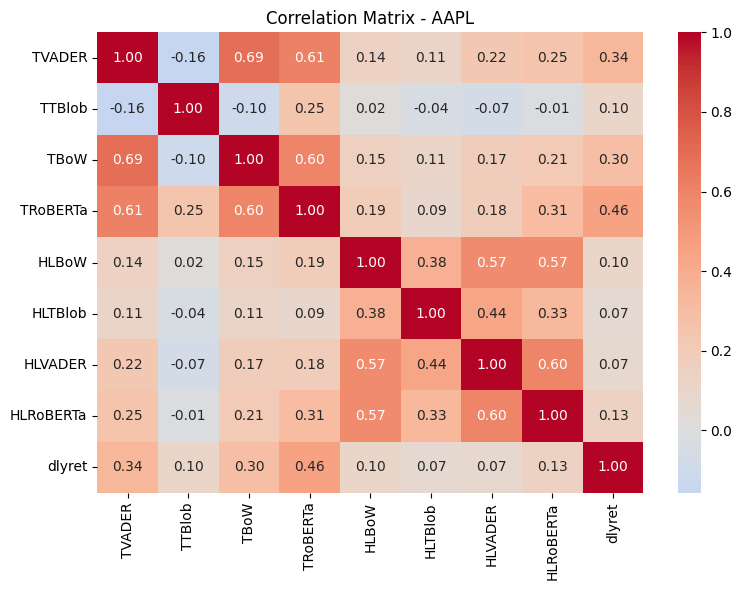

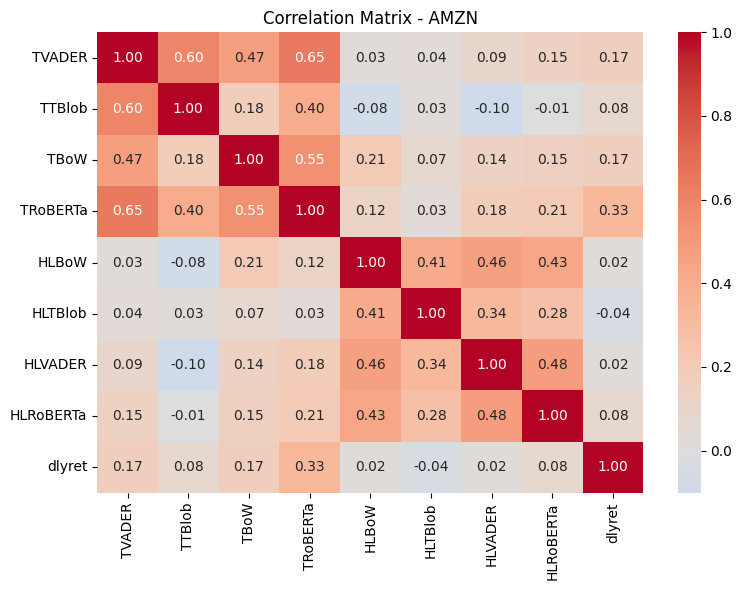

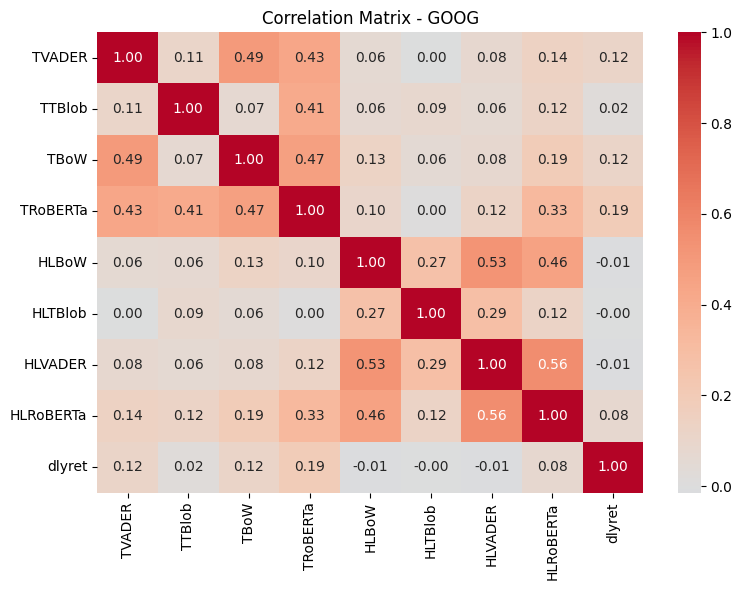

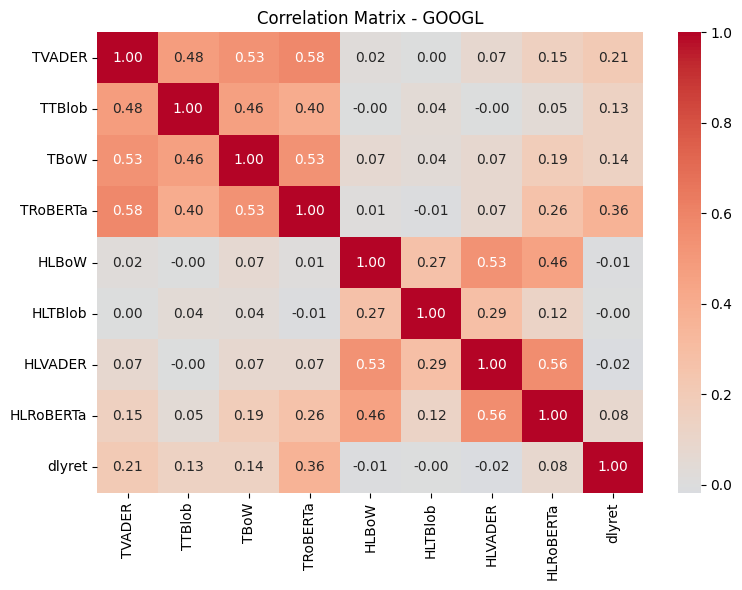

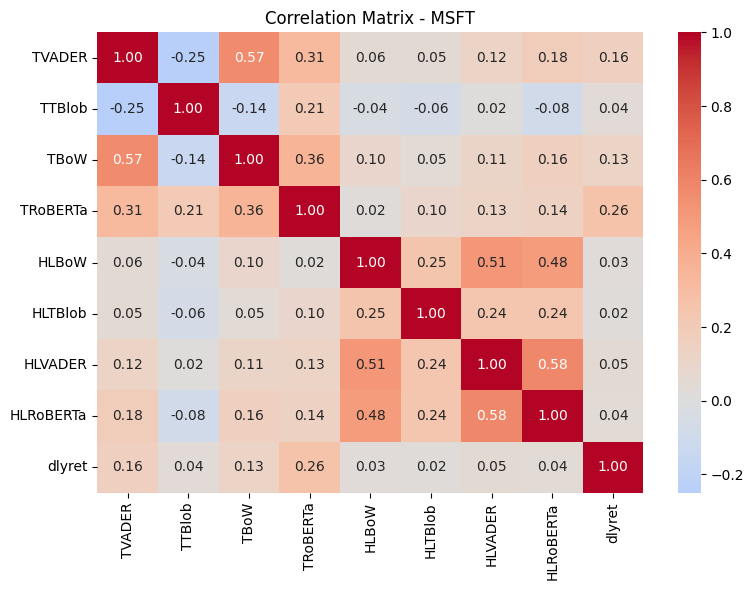

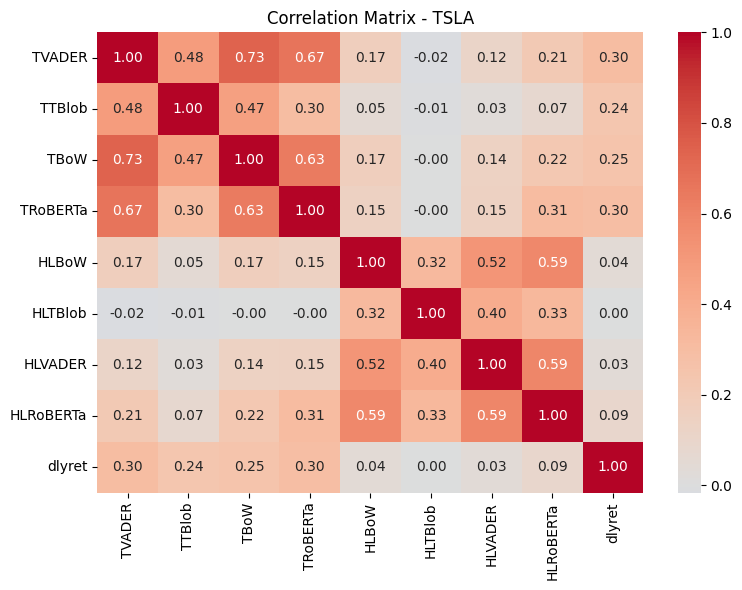

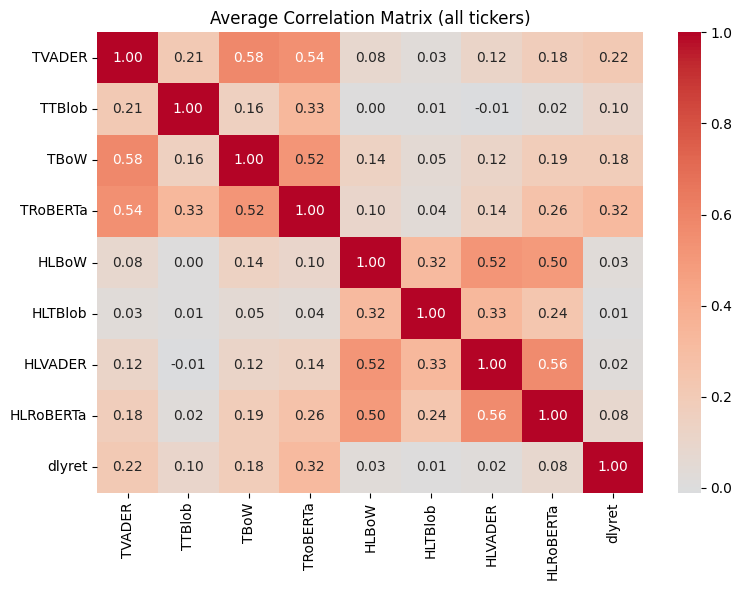

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["TVADER", "TTBlob", "TBoW", "TRoBERTa", "HLBoW", "HLTBlob", "HLVADER", "HLRoBERTa", "dlyret"]

# Per ticker
for ticker in tickers:
    plt.figure(figsize=(8, 6))
    sns.heatmap(dfs[ticker][cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title(f'Correlation Matrix - {ticker}')
    plt.tight_layout()
    plt.show()

# Overall
corr_sum = None
for ticker in tickers:
    corr = dfs[ticker][cols].corr()
    if corr_sum is None:
        corr_sum = corr
    else:
        corr_sum += corr

corr_mean = corr_sum / len(tickers)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mean, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix (all tickers)')
plt.tight_layout()
plt.show()

## **III. Methods & models**

### **III.A. HD-SURDLM (Heterogeneous Dynamic Seemingly Unrelated Regression with Dynamic Linear Models) model**

Pros of this model: 

- takes into account multi-dimensional time-varying features
- cross-sectional stock analysis: correlations and spillover over assets, better than single-stock models

The extended model is articulated as: 

$$\begin{align}
&y_{j,t}=\alpha_J+(\sum^K_{k=1}X_{j,t,k}\beta_{j,t,k}) + Z_{j,t}\gamma_j / u_{j,t} \\
&\beta_{j,t,k}=\beta_{j,t-1,k}+v_{j,t,k}
\end{align}
$$

where 
- $j= 1,... , M$ denotes individual stocks
- $t = 1,... , T$ represents discrete time points
- $k= 1,... , K$ indexes over the time-varying features. 

It comprises:
- stock-specific intercepts $\alpha_j$
- time-varying features $X_{j, t, k}$ with coefficients $\beta_{j,t,k}$
- non-time-varying features $Z_{j,t}$ with coefficients $\gamma_j$. 

The model accounts for observation errors $u_{j,t} \sim \mathcal{N}_M(0, \Omega)$ and system errors $v_{j,t,k} \sim \mathcal{N}(0, \Omega)$, which are independent across time and features, with a covariance structure $\sum = A\Omega A$. 

The unknown parameters $\Theta = \{\alpha_j,\beta_{j,t,k},\gamma_j,\Omega\}_{j=1,...,M;t=1,...,T}$ collectively capture stock-specific effects, time-varying relationships, and error structures, enhancing the model’s adaptability to complex, dynamic stock return patterns across multiple assets. 

The model utilizes collected data $D=\{ y_{j,t},X_{j,t,k}, Z_{j,t}\}$, enabling a comprehensive analysis of multi-asset stock returns while accounting for both time-varying and static influences.


 
- $\alpha_j$ serves as the intercept for each stock $j$, epitomizing the intrisinc level of returns in the absence of influence by other variables. 

- The coefficients $\beta_{j,t,k}$ are pivotal, representing the time-varying impact of the $k$ th predictor $X_{j,t,k}$ on the returns of stock $j$ at time $t$ (they may evolve as per $\beta_{j,t,k}=\beta_{j,t-1,k}+v_{j,t,k}$), portraying the temporal variations in the relationships between predictors and returns.

- The model incorporate $\gamma_j$, the set of coefficients corresponding to the predictor vector Z_{j,t} for each stock $j$. Although these coefficient are static across time, their random nature allows fot th emodulation of the the predictors’ impact on returns.

- $\Omega$, encompassed within the unknown parameter vector $\Theta$, is not explicitly defined in the provided context but is potentially indicative of the variance–covariance matrix of the error terms, thereby capturing the variances and correlations in the model residuals.

- The model accommodates error terms representing the observation error and system error, respectively. $u_{j,t}$ accounts for the unexplained variability in stock returns. $v_{j,t,k}$ signifies the fluctuations in the time-varying regression coefficients, thereby contributing to the dynamic nature of the model. 

Collectively, the incorporation of these random parameters enhances the model’s adaptability and proficiency in capturing the multifaceted relationships between various predictors and stock returns across diverse stocks and temporal instances.




We begin by building the feature matrix. For both t+1 and t+7 targets, we use t sentiment and financial metrics.
- t+1 : target is return from t+1 MO to t+1 MC
- t+7: target is return from t+1 MO to t+8 MO
- t+7 alternative: target is return from t+1 MO to t+7 MC

**For sentiment features**
- Model 1: General daily average
- Model 2: General daily weighted average for Tweets
- Model 3: Twitter uses VADER, news uses TB
- Model 4: RoBERTa is used for all
- Can test only Tweet/ only headlines, with each method, or 2 combination, or 3 combinations.

#### **III.B. Stabilized Gibbs samplings**

*Gibbs sampling is a Markov chain Monte Carlo (MCMC) algorithm used for sampling from a multivariate probability distribution when direct sampling is difficult, by sampling from the conditional distributions of each variable.*

We introduce a novel, stable Gibbs sampling approach that not only enhances performance but also effectively handles multiple assets, uncovering potential inter-asset relationships.

*Sampling $\alpha$ and $\gamma$*. We sample the intercept vector $\alpha=(\alpha_1,...,\alpha_m)$ and the non-time-varying coefficient matric $\gamma=(\gamma_1,...,\gamma_M)$:

$(\alpha | D, \Theta \setminus \{\alpha\}) \sim \mathcal{N}(\mu_{\alpha}, \Sigma_{\alpha})$

$(\gamma | D, \Theta \setminus \{\gamma\}) \sim \mathcal{N}_{M \times p}(\mu_{\gamma}, \Sigma_{\gamma})$

where $D$ represents the data, $\Theta$ is the set of all parameters, and $p$ is the number of non-time-varying predictors. $\mu_{\alpha}$, $\Sigma_{\alpha}$, $\mu_{\gamma}$, and $\Sigma_{\gamma}$ are derived from the full conditional distributions.

Sampling $\beta$. We sample the time-varying coefficient tensors $\beta = (\beta_{1,t,k}, \dots, \beta_{M,t,k})$ for each time-varying feature $k = 1, \dots, K$:

$(\beta_{\cdot,\cdot,k} | D, \Theta \setminus \{\beta_{\cdot,\cdot,k}\}) \sim \mathcal{N}_{M \times T}(\mathbf{H}_k, \mathbf{B}_k)$

We use an improved Filter Forward Backward Sampling (FFBS) algorithm that processes all M stocks concurrently:
1. Forward filtration: Compute $\mathbf{m}_t$ and $\mathbf{C}_t$ sequentially for $t = 1, \dots, T$.
2. Backward sampling: For $t = T, \dots, 1$, sample
$\boldsymbol{\beta}_t \sim \mathcal{N}_M(\mathbf{h}_t, \mathbf{B}_t),$
where:

$\mathbf{h}_t = \mathbf{m}_t + \mathbf{C}_t \mathbf{R}_{t+1}^{-1} (\mathbf{m}_{t+1} - \mathbf{m}_t),$

$\mathbf{B}_t = \mathbf{C}_t + \mathbf{C}_t \mathbf{R}_{t+1}^{-1} \mathbf{B}_{t+1} \mathbf{R}_{t+1}^{-1} \mathbf{C}_t - \mathbf{C}_t \mathbf{R}_{t+1}^{-1} \mathbf{C}_t.$

This modification enhances numerical stability by using the computed mean $\mathbf{m}_{t+1}$ instead of the randomly sampled $\boldsymbol{\beta}_{t+1}$, reducing the accumulation of randomness in the backward sampling step.

Sampling $\boldsymbol{\Omega}$. We sample the joint variance–covariance matrix $\boldsymbol{\Omega}$, which captures cross-stock error correlations:
$(\boldsymbol{\Omega} | D \setminus \{\boldsymbol{\beta}\}, \Theta \setminus \{\boldsymbol{\Omega}\}) \sim \mathcal{IW}^{-1}(\nu, \boldsymbol{\Psi}),$

where:

$\nu = T - M + 2,$

$$\boldsymbol{\Psi} = \sum_{t=1}^{T} \mathbf{u}_t \mathbf{u}_t^\top. \tag{17}$$

We do not incorporate $\mathbf{v}_t$ (the difference between consecutive $\boldsymbol{\beta}_t$) in the sampling process. Instead, we recommend estimating $\boldsymbol{\Sigma}$ after the Gibbs sampling to ensure stability and prevent potential "viscous cycles" that could hinder convergence.

This novel approach allows for a more stable estimation of the overall model parameters, preventing situations where errors in estimating $\boldsymbol{\Omega}$ and $\boldsymbol{\beta}$ can reinforce each other, leading to poor convergence or instability in the Gibbs sampler.

Multi-step forecasting. We introduce a flexible approach to multi-step forecasting that accounts for increasing uncertainty across all M stocks simultaneously:

$\mathbf{Y}_{T+N} \sim \mathcal{N}_M(\boldsymbol{\mu}_{T+N}, \boldsymbol{\Sigma}_{T+N}),$

$\boldsymbol{\mu}_{T+N} = \boldsymbol{\alpha} + \mathbf{X}_{T+N} \mathbf{m}_T + \mathbf{Z}_{T+N} \boldsymbol{\gamma},$

$\boldsymbol{\Sigma}_{T+N} = \mathbf{F}_{T+N} (\mathbf{C}_N + T \boldsymbol{\Sigma}) \mathbf{F}_{T+N}^\top + \boldsymbol{\Omega}.$

Here, $\mathbf{Y}_{T+N}$ is an M-dimensional vector of stock returns, $\boldsymbol{\alpha}$ is the M-dimensional vector of intercepts, $\mathbf{X}_{T+N}$ and $\mathbf{Z}_{T+N}$ are matrices of time-varying and non-time-varying predictors for all M stocks, $\mathbf{m}_T$ is the matrix of final state estimates for the time-varying coefficients, and $\boldsymbol{\gamma}$ is the matrix of non-time-varying coefficients. $\mathbf{F}_{T+N}$ is a block-diagonal matrix of the time-varying predictors, $\mathbf{C}_N$ is the covariance matrix of the state estimates, and $\boldsymbol{\Omega}$ is the $M \times M$ cross-sectional covariance matrix of the errors.

This formulation allows for a more accurate representation of forecast uncertainty as the prediction horizon ($N$) increases while also capturing cross-sectional dependencies between stocks. The covariance matrix $\boldsymbol{\Sigma}_{T+N}$ grows with $N$, reflecting the increased uncertainty in longer-term forecasts, and its off-diagonal elements represent the co-movement of stock returns in future predictions.


We set a simpliefid model running on half on the sample, with 2000 and 500 settings, and fill of mising values with an EWMA on past 5 windows with a 0.5 delta. We itterate on all individual tweet sentiment method combination (15), all headlines sentiment combinations (15) as well as all tweeter and headlines sentiment combination combos (15*15) for all three averaging method. We also test tweets using only overnight sentiment (from t market close to t+1 market open).

We notice that the log-weighted average on tweet metrics performs better than the two other averaging methods. By lowest R2 (still negative), the top 5 models are: 
- T=VADER | HL=RoBERTa+BoW+TBlob+VADER
- T=VADER | HL=VADER
- T=VADER | HL=BoW+TBlob+VADER
- overnight T=VADER
- overnight T=TBlob+VADER

For highest hit-rate, the top 5 is: 
- HL=VADER 
- overnight T=VADER
- T=VADER
- overnight T=TBlob
- T=BoW+VADER | HL=VADER	

For combining highest hit-rate and highest-r^2, the top 5 is: 
- T=VADER
- HL=VADER
- overnight T=VADER
- overnight T=TBlob
- T=VADER | HL=BoW+VADER

We hence shortlist the 10 following models, all using the log-weighted average: 
- T=VADER | HL=RoBERTa+BoW+TBlob+VADER
- T=VADER | HL=VADER
- T=VADER | HL=BoW+TBlob+VADER
- overnight T=VADER
- overnight T=TBlob+VADER
- HL=VADER
- T=VADER
- overnight T=TBlob
- T=BoW+VADER | HL=VADER
- T=VADER | HL=BoW+VADER
- overnight V2 T=BoW
- overnight V2 T=BoW+VADER

After shortlising results for ret1, we also iterate on 720 possibilities for ret7, and later ret8, testing all of these combos: 


**MODELS**
overnight V2 T=BoW 
overnight V2 T=BoW+VADER
overnight T=TBlob
overnight T=VADER
overnight T=TBlob+VADER
T=BoW
T=VADER
T=BoW+VADER
HL=BoW
HL=VADER
HL=BoW+VADER
T=VADER | HL=BoW
T=VADER | HL=BoW+VADER
T=VADER | HL=BoW+TBlob+VADER 
T=BoW+VADER | HL=VADER

**Data averaging**
No average
AVG 4
AVG 6
AVG 8
AVG 10

EWMA 3, 0.3
EWMA 4, 0.1
EWMA 4, 0.3
EWMA 4, 0.7
EWMA 5, 0.1
EWMA 6, 0.1
EWMA 6, 0.3
EWMA 6, 0.7
EWMA 8, 0.1
EWMA 8, 0.7
EWMA 10, 0.7

**Delta**
0.9
0.98
0.95

### **III. B. Benchmark models**

For benchmark models, the paper uses RandomForest, SVR, LASSO, MLP, RNN, LSTM and SURDLM. We also use a hybrid CNN-LSTM and DRL. We run them both as classifiers (up/down) and as continuous models as a benchmark for the HD-SURLM model.

In [43]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "torch"])

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


0

In [53]:
import pandas as pd 

dfAAPL = pd.read_csv("data/training/AAPL_AVG1.csv", index_col=0, parse_dates=True)
dfAMZN = pd.read_csv("data/training/AMZN_AVG1.csv", index_col=0, parse_dates=True)
dfGOOG = pd.read_csv("data/training/GOOG_AVG1.csv", index_col=0, parse_dates=True)
dfGOOGL = pd.read_csv("data/training/GOOGL_AVG1.csv", index_col=0, parse_dates=True)
dfMSFT = pd.read_csv("data/training/MSFT_AVG1.csv", index_col=0, parse_dates=True)
dfTSLA = pd.read_csv("data/training/TSLA_AVG1.csv", index_col=0, parse_dates=True)

dfs = {"AAPL": dfAAPL, "AMZN": dfAMZN, "GOOG": dfGOOG, "GOOGL": dfGOOGL, "MSFT": dfMSFT, "TSLA": dfTSLA}

We first define two versions of X and Y features, with both continuous and binary features.

In [56]:
import numpy as np

tickers = ["AAPL", "AMZN", "GOOG", "GOOGL", "MSFT", "TSLA"]

def ewma_weights(window_vals, alpha):
      weights = (1 - alpha) ** np.arange(len(window_vals))[::-1]
      return np.sum(weights * window_vals) / np.sum(weights)

for ticker in tickers: 
    # For missing tweets: ffil. For missing headlines: ewma 5d 0.5
    dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]] = dfs[ticker][["TVADER", "TTBlob", "TBoW", "TRoBERTa"]].ffill().fillna(0)
    dfs[ticker][["HLBoW", "HLTBlob", "HLVADER", "HLRoBERTa"]] = dfs[ticker][["HLBoW", "HLTBlob", "HLVADER","HLRoBERTa"]].apply(lambda col: col.dropna().rolling(window=5, min_periods=1).apply(lambda w: ewma_weights(w.values, 0.5)).reindex(dfs[ticker].index, method='ffill')).fillna(0)

    dfs[ticker]["T_SENT"] = dfs[ticker][["TVADER"]].mean(axis=1)
    dfs[ticker]["HL_SENT"] = dfs[ticker][["HLBoW", "HLTBlob", "HLVADER"]].mean(axis=1)   


# Creating binary variables
for ticker in tickers:
    for col in ["dlyret", "past_3ret", "past_7ret", "ret1", "ret7"]:
        dfs[ticker][f"{col}B"] = (dfs[ticker][col] > 0).astype(int)
    

# Continuous features and target
feature_cols = [
    "dlyret", "past_3ret", "past_7ret", "volumeSPX",
    "dlyretSPX", "VIX", "T_SENT", "HL_SENT",
]

target_col = "ret1"

# Binary features and target

feature_colsB = [
    "dlyretB", "past_3retB", "past_7retB", "volumeSPX",
    "dlyretSPX", "VIX", "T_SENT", "HL_SENT",
]

target_col = "ret1B"


## **1. RandomForest**

Running as both a classifier as a continuous regressor.

In [63]:
from sklearn.metrics import r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

def run_RnDFor(feature_cols, target_col, is_classification=False):

    results = []

    for ticker in tickers:
        df_ticker = dfs[ticker].copy()
        df_ticker = df_ticker.sort_index().iloc[:629].copy()

        cols_needed = feature_cols + [target_col]
        df_ticker = df_ticker[cols_needed].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train = df_ticker.iloc[:split_idx]
        test = df_ticker.iloc[split_idx:]

        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = test[feature_cols]
        y_test = test[target_col]

        if is_classification:
            
            model = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)

            results.append({"ticker": ticker,"accuracy": accuracy,"precision": precision,"recall": recall,"f1": f1,})

        else:
            model = RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=5, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_pred_bin = (y_pred > 0).astype(int)
            y_test_bin = (y_test > 0).astype(int)


            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))
            r2 = r2_score(y_test, y_pred)
            precision = precision_score(y_test_bin, y_pred_bin)
            recall = recall_score(y_test_bin, y_pred_bin)
            f1 = f1_score(y_test_bin, y_pred_bin)

            results.append({"ticker": ticker, "hit_rate": hit_rate, "r2_oos": r2, "precision": precision, "recall": recall, "f1": f1})

    return pd.DataFrame(results)
    
results_df = pd.DataFrame(results)

results_reg = run_RnDFor(feature_cols, "ret1", is_classification=False)
results_clf = run_RnDFor(feature_colsB, "ret1B", is_classification=True)

print(results_reg)
print(f"Mean hit rate: {results_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_reg['r2_oos'].mean():.4f}")
print(f"Mean precision OOS: {results_reg['precision'].mean():.4f}")
print(f"Mean recall OOS: {results_reg['recall'].mean():.4f}")
print(f"Mean F1 OOS: {results_reg['f1'].mean():.4f}\n")

print(results_clf)
print(f"Mean accuracy: {results_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_clf['f1'].mean():.4f}")

  ticker  hit_rate    r2_oos  precision    recall        f1
0   AAPL  0.515873 -0.066043   0.534247  0.590909  0.561151
1   AMZN  0.515873 -0.076175   0.552632  0.323077  0.407767
2   GOOG  0.531746 -0.081125   0.666667  0.447368  0.535433
3  GOOGL  0.476190 -0.087892   0.585366  0.328767  0.421053
4   MSFT  0.460317 -0.079654   0.493827  0.597015  0.540541
5   TSLA  0.492063 -0.057504   0.512821  0.606061  0.555556
Mean hit rate: 0.4987
Mean R2 OOS: -0.0747
Mean precision OOS: 0.5576
Mean recall OOS: 0.4822
Mean F1 OOS: 0.5036

  ticker  accuracy  precision    recall        f1
0   AAPL  0.523810   0.531250  0.772727  0.629630
1   AMZN  0.507937   0.531915  0.384615  0.446429
2   GOOG  0.492063   0.611111  0.434211  0.507692
3  GOOGL  0.420635   0.500000  0.328767  0.396694
4   MSFT  0.476190   0.507246  0.522388  0.514706
5   TSLA  0.515873   0.538462  0.530303  0.534351
Mean accuracy: 0.4894
Mean precision: 0.5367
Mean recall: 0.4955
Mean F1: 0.5049


## **2. Lasso**

For this secondary benchmark, we first scale the features.

In [70]:
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def run_Lasso(feature_cols, target_col, is_classification=False):

    results = []

    for ticker in tickers:
        df_ticker = dfs[ticker].copy()
        df_ticker = df_ticker.sort_index().iloc[:629].copy()

        cols_needed = feature_cols + [target_col]
        df_ticker = df_ticker[cols_needed].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train = df_ticker.iloc[:split_idx]
        test = df_ticker.iloc[split_idx:]

        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = test[feature_cols]
        y_test = test[target_col]

        if is_classification:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("logistic", LogisticRegressionCV(
                    Cs=np.logspace(-4, 0, 50),
                    cv=5,
                    max_iter=10000,
                    random_state=42,
                    n_jobs=-1,
                ))
            ])
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "C": model.named_steps["logistic"].C_[0]
            })
            
        else:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("lasso", LassoCV(
                    alphas=np.logspace(-4, 0, 50),
                    cv=5,
                    max_iter=10000,
                    random_state=42
                ))
            ])
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_test_bin = (y_test > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))
            r2 = r2_score(y_test, y_pred)
            precision = precision_score(y_test_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_test_bin, y_pred_bin)
            f1 = f1_score(y_test_bin, y_pred_bin)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "alpha": model.named_steps["lasso"].alpha_
            })
    
    return pd.DataFrame(results)

results_lasso_reg = run_Lasso(feature_cols, "ret1", is_classification=False)
results_lasso_clf = run_Lasso(feature_colsB, "ret1B", is_classification=True)

print(results_lasso_reg)
print(f"Mean hit rate: {results_lasso_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_lasso_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_lasso_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_lasso_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_lasso_reg['f1'].mean():.4f}")

print(results_lasso_clf)
print(f"Mean accuracy: {results_lasso_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_lasso_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_lasso_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_lasso_clf['f1'].mean():.4f}")

  ticker  hit_rate    r2_oos  precision    recall        f1     alpha
0   AAPL  0.476190 -0.021050   0.000000  0.000000  0.000000  1.000000
1   AMZN  0.468254 -0.002921   0.486842  0.569231  0.524823  0.000954
2   GOOG  0.396825 -0.006556   0.000000  0.000000  0.000000  1.000000
3  GOOGL  0.420635 -0.004090   0.000000  0.000000  0.000000  1.000000
4   MSFT  0.531746 -0.015294   0.531746  1.000000  0.694301  1.000000
5   TSLA  0.523810 -0.011061   0.523810  1.000000  0.687500  0.002024
Mean hit rate: 0.4696
Mean R2 OOS: -0.0102
Mean precision: 0.2571
Mean recall: 0.4282
Mean F1: 0.3178
  ticker  accuracy  precision    recall        f1         C
0   AAPL  0.523810   0.523810  1.000000  0.687500  0.002947
1   AMZN  0.492063   0.514286  0.276923  0.360000  0.001151
2   GOOG  0.436508   0.666667  0.131579  0.219780  0.004292
3  GOOGL  0.579365   0.579365  1.000000  0.733668  0.000450
4   MSFT  0.523810   0.545455  0.626866  0.583333  0.003556
5   TSLA  0.507937   0.562500  0.272727  0.36734

## **SVR**

In [72]:
from sklearn.svm import SVR, SVC

def run_SVM(feature_cols, target_col, is_classification=False):

    results = []

    for ticker in tickers: 
        df_ticker = dfs[ticker].copy()
        df_ticker = df_ticker.sort_index().iloc[:629].copy()

        cols_needed = feature_cols + [target_col]
        df_ticker = df_ticker[cols_needed].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train = df_ticker.iloc[:split_idx]
        test = df_ticker.iloc[split_idx:]

        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = test[feature_cols]
        y_test = test[target_col]

        if is_classification:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("svc", SVC(kernel="rbf", C=1.0, random_state=42, class_weight='balanced'))
            ])
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
            
        else:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1))
            ])
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_test_bin = (y_test > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))
            r2 = r2_score(y_test, y_pred)
            precision = precision_score(y_test_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_test_bin, y_pred_bin, zero_division=0)
            f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
    
    return pd.DataFrame(results)

results_svm_reg = run_SVM(feature_cols, "ret1", is_classification=False)
results_svm_clf = run_SVM(feature_colsB, "ret1B", is_classification=True)

print(results_svm_reg)
print(f"Mean hit rate: {results_svm_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_svm_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_svm_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_svm_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_svm_reg['f1'].mean():.4f}\n")

print(results_svm_clf)
print(f"Mean accuracy: {results_svm_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_svm_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_svm_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_svm_clf['f1'].mean():.4f}")

  ticker  hit_rate    r2_oos  precision  recall      f1
0   AAPL  0.523810 -1.246761    0.52381     1.0  0.6875
1   AMZN  0.484127 -5.515785    0.00000     0.0  0.0000
2   GOOG  0.396825 -1.642285    0.00000     0.0  0.0000
3  GOOGL  0.420635 -1.241047    0.00000     0.0  0.0000
4   MSFT  0.468254 -0.005009    0.00000     0.0  0.0000
5   TSLA  0.523810 -0.000854    0.52381     1.0  0.6875
Mean hit rate: 0.4696
Mean R2 OOS: -1.6086
Mean precision: 0.1746
Mean recall: 0.3333
Mean F1: 0.2292

  ticker  accuracy  precision    recall        f1
0   AAPL  0.579365   0.586667  0.666667  0.624113
1   AMZN  0.444444   0.432432  0.246154  0.313725
2   GOOG  0.500000   0.632653  0.407895  0.496000
3  GOOGL  0.547619   0.617647  0.575342  0.595745
4   MSFT  0.531746   0.557143  0.582090  0.569343
5   TSLA  0.555556   0.562500  0.681818  0.616438
Mean accuracy: 0.5265
Mean precision: 0.5648
Mean recall: 0.5267
Mean F1: 0.5359


## **MLP**

In [91]:
from sklearn.neural_network import MLPRegressor, MLPClassifier

def run_MLP(feature_cols, target_col, is_classification=False):

    results = []

    for ticker in tickers:
        df_ticker = dfs[ticker].copy()
        df_ticker = df_ticker.sort_index().iloc[:629].copy()

        cols_needed = feature_cols + [target_col]
        df_ticker = df_ticker[cols_needed].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train = df_ticker.iloc[:split_idx]
        test = df_ticker.iloc[split_idx:]

        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = test[feature_cols]
        y_test = test[target_col]

        # Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        if is_classification:
            model = MLPClassifier(
                hidden_layer_sizes=(50, 50),
                activation='relu',
                solver='adam',
                alpha=0.001,
                batch_size='auto',
                learning_rate='constant',
                learning_rate_init=0.001,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=10,
                random_state=42
            )
            
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
            
        else:
            model = MLPRegressor(
                hidden_layer_sizes=(50, 50),
                activation='relu',
                solver='adam',
                alpha=0.001,
                batch_size='auto',
                learning_rate='constant',
                learning_rate_init=0.001,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=10,
                random_state=42
            )
            
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_test_bin = (y_test > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_test))
            r2 = r2_score(y_test, y_pred)
            precision = precision_score(y_test_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_test_bin, y_pred_bin, zero_division=0)
            f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
    
    return pd.DataFrame(results)

results_mlp_reg = run_MLP(feature_cols, "ret1", is_classification=False)
results_mlp_clf = run_MLP(feature_colsB, "ret1B", is_classification=True)

print(results_mlp_reg)
print(f"Mean hit rate: {results_mlp_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_mlp_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_mlp_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_mlp_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_mlp_reg['f1'].mean():.4f}\n")

print(results_mlp_clf)
print(f"Mean accuracy: {results_mlp_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_mlp_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_mlp_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_mlp_clf['f1'].mean():.4f}")

  ticker  hit_rate     r2_oos  precision    recall        f1
0   AAPL  0.476190 -18.006149   0.500000  0.393939  0.440678
1   AMZN  0.539683 -19.490638   0.550725  0.584615  0.567164
2   GOOG  0.420635 -18.582699   0.523810  0.434211  0.474820
3  GOOGL  0.507937 -40.877685   0.579710  0.547945  0.563380
4   MSFT  0.539683 -15.083837   0.558442  0.641791  0.597222
5   TSLA  0.547619  -3.575471   0.588235  0.454545  0.512821
Mean hit rate: 0.5053
Mean R2 OOS: -19.2694
Mean precision: 0.5502
Mean recall: 0.5095
Mean F1: 0.5260

  ticker  accuracy  precision    recall        f1
0   AAPL  0.492063   0.513158  0.590909  0.549296
1   AMZN  0.484127   0.500000  0.015385  0.029851
2   GOOG  0.388889   0.428571  0.039474  0.072289
3  GOOGL  0.412698   0.476190  0.136986  0.212766
4   MSFT  0.484127   0.555556  0.149254  0.235294
5   TSLA  0.555556   0.613636  0.409091  0.490909
Mean accuracy: 0.4696
Mean precision: 0.5145
Mean recall: 0.2235
Mean F1: 0.2651


## **RNN**

With 8 features and 1 target, we use the multivariate time series model given in the class. Requires Python ≤ 3.10.x.

In [92]:
import tensorflow as tf


def run_RNN(feature_cols, target_col, is_classification=False):

    results = []

    SEQ_LENGTH = 40
    BATCH_SIZE = 32
    EPOCHS = 500
    PATIENCE = 50

    for ticker in tickers:

        df_ticker = dfs[ticker].copy().sort_index().iloc[:629]
        cols = feature_cols + [target_col]
        df_ticker = df_ticker[cols].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train_df = df_ticker.iloc[:split_idx]
        test_df = df_ticker.iloc[split_idx:]

        # Scaling
        scaler_X = StandardScaler()
        scaler_y = StandardScaler() 

        X_train = scaler_X.fit_transform(train_df[feature_cols].values)
        y_train = scaler_y.fit_transform(train_df[[target_col]].values).flatten()
        X_test = scaler_X.transform(test_df[feature_cols].values)
        y_test = scaler_y.transform(test_df[[target_col]].values).flatten()

        train_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_train,
            targets=y_train[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=42
        )
        test_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_test,
            targets=y_test[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        if is_classification:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.SimpleRNN(32),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_proba = model.predict(test_ds).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
            y_true = (y_test[SEQ_LENGTH:] > 0).astype(int)
            
            accuracy = accuracy_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
            
        else:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.SimpleRNN(32),
                tf.keras.layers.Dense(1)
            ])
            
            model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_mae', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_scaled = model.predict(test_ds).flatten()
            y_true_scaled = y_test[SEQ_LENGTH:]
            
            y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
            y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_true_bin = (y_true > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_true))
            r2 = r2_score(y_true, y_pred)
            precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
            f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
    
    return pd.DataFrame(results)

results_rnn_reg = run_RNN(feature_cols, "ret1", is_classification=False)
results_rnn_clf = run_RNN(feature_colsB, "ret1B", is_classification=True)

# Affichage
print(results_rnn_reg)
print(f"Mean hit rate: {results_rnn_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_rnn_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_rnn_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_rnn_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_rnn_reg['f1'].mean():.4f}\n")

print(results_rnn_clf)
print(f"Mean accuracy: {results_rnn_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_rnn_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_rnn_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_rnn_clf['f1'].mean():.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
  ticker  hit_rate    r2_oos  precision    recall        f1
0   AAPL  0.453488 -0.208242   0.310345  0.250000  0.276923
1   AMZN  0.627907 -0.162331   0.692308  0.428571  0.529412
2   GOOG  0.604651  0.010043   0.660000  0.660000  0.660000
3  GOOGL  0.430233 -0.101979   0.515152  0.340000  0.409639
4   MSFT  0.488372 -0.120166   0.518519  0.608696  0.560000
5   TSLA  0.476744 -0.120941   0.479167  0.534884  0.505495
Mean hit rate: 0.5136
Mean R2 OOS: -0.1173
Mean precision: 0.5292
Mean recall: 0.4704
Mean F1: 0.4902

  ticker  accuracy  p

## **LSTM**

In [93]:
def run_LSTM(feature_cols, target_col, is_classification=False):
    
    results = []

    # Config
    SEQ_LENGTH = 40 
    BATCH_SIZE = 32
    EPOCHS = 500
    PATIENCE = 50

    for ticker in tickers:

        df_ticker = dfs[ticker].copy().sort_index().iloc[:629]
        cols = feature_cols + [target_col]
        df_ticker = df_ticker[cols].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train_df = df_ticker.iloc[:split_idx]
        test_df = df_ticker.iloc[split_idx:]

        # Scaling
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        X_train = scaler_X.fit_transform(train_df[feature_cols].values)
        y_train = scaler_y.fit_transform(train_df[[target_col]].values).flatten()
        X_test = scaler_X.transform(test_df[feature_cols].values)
        y_test = scaler_y.transform(test_df[[target_col]].values).flatten()

        train_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_train,
            targets=y_train[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=42
        )
        test_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_test,
            targets=y_test[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        if is_classification:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.LSTM(32),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_proba = model.predict(test_ds).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
            y_true = (y_test[SEQ_LENGTH:] > 0).astype(int)
            
            accuracy = accuracy_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
            
        else:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.LSTM(32),
                tf.keras.layers.Dense(1)
            ])
            
            model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_mae', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_scaled = model.predict(test_ds).flatten()
            y_true_scaled = y_test[SEQ_LENGTH:]
            
            y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
            y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_true_bin = (y_true > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_true))
            r2 = r2_score(y_true, y_pred)
            precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
            f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
    
    return pd.DataFrame(results)

results_lstm_reg = run_LSTM(feature_cols, "ret1", is_classification=False)
results_lstm_clf = run_LSTM(feature_colsB, "ret1B", is_classification=True)


print(results_lstm_reg)
print(f"Mean hit rate: {results_lstm_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_lstm_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_lstm_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_lstm_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_lstm_reg['f1'].mean():.4f}\n")

print(results_lstm_clf)
print(f"Mean accuracy: {results_lstm_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_lstm_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_lstm_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_lstm_clf['f1'].mean():.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
  ticker  hit_rate    r2_oos  precision    recall        f1
0   AAPL  0.604651 -0.047149   1.000000  0.055556  0.105263
1   AMZN  0.511628 -0.011937   0.500000  0.047619  0.086957
2   GOOG  0.581395 -0.037959   0.684211  0.520000  0.590909
3  GOOGL  0.546512 -0.005822   0.761905  0.320000  0.450704
4   MSFT  0.476744  0.008178   0.512195  0.456522  0.482759
5   TSLA  0.500000  0.015527   0.500000  0.116279  0.188679
Mean hit rate: 0.5368
Mean R2 OOS: -0.0132
Mean precision: 0.6597
Mean recall: 0.2527
Mean F1: 0.3175

  ticker  accuracy  p

## **CNN-LSTM**


In [94]:
def run_CNN_LSTM(feature_cols, target_col, is_classification=False):

    results = []

    # Config
    SEQ_LENGTH = 40 
    BATCH_SIZE = 32
    EPOCHS = 500
    PATIENCE = 50

    for ticker in tickers:

        df_ticker = dfs[ticker].copy().sort_index().iloc[:629]
        cols = feature_cols + [target_col]
        df_ticker = df_ticker[cols].dropna()

        split_idx = int(len(df_ticker) * 0.8)
        train_df = df_ticker.iloc[:split_idx]
        test_df = df_ticker.iloc[split_idx:]

        # Scaling
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        X_train = scaler_X.fit_transform(train_df[feature_cols].values)
        y_train = scaler_y.fit_transform(train_df[[target_col]].values).flatten()
        X_test = scaler_X.transform(test_df[feature_cols].values)
        y_test = scaler_y.transform(test_df[[target_col]].values).flatten()

        train_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_train,
            targets=y_train[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=42
        )
        test_ds = tf.keras.utils.timeseries_dataset_from_array(
            X_test,
            targets=y_test[SEQ_LENGTH:],
            sequence_length=SEQ_LENGTH,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        if is_classification:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
                tf.keras.layers.MaxPooling1D(pool_size=2),
                tf.keras.layers.LSTM(32),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
            
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_proba = model.predict(test_ds).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)
            y_true = (y_test[SEQ_LENGTH:] > 0).astype(int)
            
            accuracy = accuracy_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
            
        else:
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=(SEQ_LENGTH, len(feature_cols))),
                tf.keras.layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
                tf.keras.layers.MaxPooling1D(pool_size=2),
                tf.keras.layers.LSTM(32),
                tf.keras.layers.Dense(1)
            ])
            
            model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
            
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_mae', patience=PATIENCE, restore_best_weights=True
            )
            
            model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS, 
                      callbacks=[early_stop], verbose=0)
            
            y_pred_scaled = model.predict(test_ds).flatten()
            y_true_scaled = y_test[SEQ_LENGTH:]
            
            y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
            y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
            
            y_pred_bin = (y_pred > 0).astype(int)
            y_true_bin = (y_true > 0).astype(int)
            
            hit_rate = np.mean(np.sign(y_pred) == np.sign(y_true))
            r2 = r2_score(y_true, y_pred)
            precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
            recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
            f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
            
            results.append({
                "ticker": ticker,
                "hit_rate": hit_rate,
                "r2_oos": r2,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })
    
    return pd.DataFrame(results)


results_cnn_lstm_reg = run_CNN_LSTM(feature_cols, "ret1", is_classification=False)
results_cnn_lstm_clf = run_CNN_LSTM(feature_colsB, "ret1B", is_classification=True)


print(results_cnn_lstm_reg)
print(f"Mean hit rate: {results_cnn_lstm_reg['hit_rate'].mean():.4f}")
print(f"Mean R2 OOS: {results_cnn_lstm_reg['r2_oos'].mean():.4f}")
print(f"Mean precision: {results_cnn_lstm_reg['precision'].mean():.4f}")
print(f"Mean recall: {results_cnn_lstm_reg['recall'].mean():.4f}")
print(f"Mean F1: {results_cnn_lstm_reg['f1'].mean():.4f}\n")

print(results_cnn_lstm_clf)
print(f"Mean accuracy: {results_cnn_lstm_clf['accuracy'].mean():.4f}")
print(f"Mean precision: {results_cnn_lstm_clf['precision'].mean():.4f}")
print(f"Mean recall: {results_cnn_lstm_clf['recall'].mean():.4f}")
print(f"Mean F1: {results_cnn_lstm_clf['f1'].mean():.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
  ticker  hit_rate    r2_oos  precision    recall        f1
0   AAPL  0.488372 -0.028663   0.277778  0.138889  0.185185
1   AMZN  0.500000 -0.007865   0.466667  0.166667  0.245614
2   GOOG  0.593023 -0.021024   0.653061  0.640000  0.646465
3  GOOGL  0.476744 -0.032159   0.592593  0.320000  0.415584
4   MSFT  0.546512 -0.028340   0.549296  0.847826  0.666667
5   TSLA  0.465116 -0.026676   0.451613  0.325581  0.378378
Mean hit rate: 0.5116
Mean R2 OOS: -0.0241
Mean precision: 0.4985
Mean recall: 0.4065
Mean F1: 0.4230

  ticker  accuracy  p